# LOAD DATASET

In [ ]:
import pandas as pd
import numpy as np

from google.colab import drive

drive.mount("/content/drive")

path = "/content/drive/MyDrive/Final_Dataset.csv"

df = pd.read_csv(path)

print("Dataset loaded successfully")
print("Shape:", df.shape)

display(df.head())
display(df.tail())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset loaded successfully
Shape: (50, 11)


,Job ID,Current (A),Voltage (V),Travel Speed (mm/min),Wire Feed Rate (m/min),Torch Angle (Â°),Gap Size (mm),Thickness (mm),Distortion (mm),Bead Width (mm),Result
0,J001,180.0,23.0,380.0,6.0,15.0,1.0,3.0,0.8,7.5,Pass
1,J002,190.0,24.0,350.0,6.5,15.0,2.0,4.0,1.1,8.2,Pass
2,J003,210.0,25.0,320.0,7.0,20.0,3.0,5.0,2.0,9.3,Pass
3,J004,220.0,26.0,300.0,7.5,15.0,4.0,6.0,3.2,10.7,Fail
4,J005,170.0,22.0,420.0,5.5,10.0,1.5,3.0,0.7,7.0,Pass


,Job ID,Current (A),Voltage (V),Travel Speed (mm/min),Wire Feed Rate (m/min),Torch Angle (Â°),Gap Size (mm),Thickness (mm),Distortion (mm),Bead Width (mm),Result
45,S026,236.25,27.25,265.0,8.275,20.00,4.250,9.50,4.125,11.975,Fail
46,S027,223.75,26.00,290.0,7.725,18.75,3.375,7.50,3.150,10.775,Fail
47,S028,221.25,26.00,290.0,7.575,16.25,3.125,6.50,2.850,10.325,Pass
48,S029,183.75,23.00,375.0,6.125,10.00,3.875,3.75,2.800,9.750,Fail
49,S030,181.25,23.00,385.0,5.975,10.00,2.625,3.25,1.600,8.450,Pass


# loading csv correctly

# DATA VALIDATION

In [ ]:
print("Dataset Shape:",df.shape)

Dataset Shape: (20, 11)


In [ ]:
print("Columns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Columns:
['Job ID', 'Current (A)', 'Voltage (V)', 'Travel Speed (mm/min)', 'Wire Feed Rate (m/min)', 'Torch Angle (Â°)', 'Gap Size (mm)', 'Thickness (mm)', 'Distortion (mm)', 'Bead Width (mm)', 'Result']

Data types:
Job ID                     object
Current (A)               float64
Voltage (V)               float64
Travel Speed (mm/min)     float64
Wire Feed Rate (m/min)    float64
Torch Angle (Â°)          float64
Gap Size (mm)             float64
Thickness (mm)            float64
Distortion (mm)           float64
Bead Width (mm)           float64
Result                     object
dtype: object

Missing values:
Job ID                    0
Current (A)               0
Voltage (V)               0
Travel Speed (mm/min)     0
Wire Feed Rate (m/min)    0
Torch Angle (Â°)          0
Gap Size (mm)             0
Thickness (mm)            0
Distortion (mm)           0
Bead Width (mm)           0
Result                    0
dtype: int64

Duplicate rows: 0


In [ ]:
print("\nColumns:")
print(df.columns.tolist())

print("\Missing Values:")
print(df.isnull().sum())


Columns:
['Job ID', 'Current (A)', 'Voltage (V)', 'Travel Speed (mm/min)', 'Wire Feed Rate (m/min)', 'Torch Angle (Â°)', 'Gap Size (mm)', 'Thickness (mm)', 'Distortion (mm)', 'Bead Width (mm)', 'Result']
\Missing Values:
Job ID                    0
Current (A)               0
Voltage (V)               0
Travel Speed (mm/min)     0
Wire Feed Rate (m/min)    0
Torch Angle (Â°)          0
Gap Size (mm)             0
Thickness (mm)            0
Distortion (mm)           0
Bead Width (mm)           0
Result                    0
dtype: int64


<>:4: SyntaxWarning: invalid escape sequence '\M'
<>:4: SyntaxWarning: invalid escape sequence '\M'
/tmp/ipykernel_1454/131811053.py:4: SyntaxWarning: invalid escape sequence '\M'
  print("\Missing Values:")


# Rename columns

In [ ]:
df = df.rename(columns={
    "Job ID": "Job_ID",
    "Current (A)": "Current",
    "Voltage (V)": "Voltage",
    "Travel Speed (mm/min)": "Travel_Speed",
    "Wire Feed Rate (m/min)": "Wire_Feed",
    "Torch Angle (Â°)": "Torch_Angle",
    "Gap Size (mm)": "Gap",
    "Thickness (mm)": "Thickness",
    "Distortion (mm)": "Distortion",
    "Bead Width (mm)": "Bead_Width",
    "Result": "Result"
})

print(df.columns.tolist())

['Job_ID', 'Current', 'Voltage', 'Travel_Speed', 'Wire_Feed', 'Torch_Angle', 'Gap', 'Thickness', 'Distortion', 'Bead_Width', 'Result']


# Overall Dataset Analysis

In [ ]:
print(df["Result"].value_counts())

Result
Pass    34
Fail    16
Name: count, dtype: int64


In [ ]:
print(df["Result"].value_counts())

Result
Pass    34
Fail    16
Name: count, dtype: int64


# Encoding Target
Pass encoded as 0,
Fail encoded as 1

In [ ]:
df["Failure"] = df["Result"].map({
    "Pass": 0,
    "Fail": 1
})

print(df[["Result", "Failure"]])

   Result  Failure
0    Pass        0
1    Pass        0
2    Pass        0
3    Fail        1
4    Pass        0
5    Fail        1
6    Pass        0
7    Fail        1
8    Pass        0
9    Fail        1
10   Pass        0
11   Pass        0
12   Fail        1
13   Pass        0
14   Fail        1
15   Pass        0
16   Pass        0
17   Fail        1
18   Pass        0
19   Pass        0
20   Pass        0
21   Pass        0
22   Pass        0
23   Pass        0
24   Pass        0
25   Pass        0
26   Pass        0
27   Pass        0
28   Fail        1
29   Fail        1
30   Fail        1
31   Fail        1
32   Pass        0
33   Pass        0
34   Pass        0
35   Pass        0
36   Pass        0
37   Pass        0
38   Pass        0
39   Pass        0
40   Fail        1
41   Pass        0
42   Pass        0
43   Pass        0
44   Fail        1
45   Fail        1
46   Fail        1
47   Pass        0
48   Fail        1
49   Pass        0


In [ ]:
print(df["Failure"].value_counts())

Failure
0    34
1    16
Name: count, dtype: int64


# Define the 7 ML input features

In [ ]:
features = [
    "Current",
    "Voltage",
    "Travel_Speed",
    "Wire_Feed",
    "Torch_Angle",
    "Gap",
    "Thickness"
]

X = df[features]
y = df["Failure"]

print("Features:")
print(features)

print("\nX shape:", X.shape)
print("y shape:", y.shape)


Features:
['Current', 'Voltage', 'Travel_Speed', 'Wire_Feed', 'Torch_Angle', 'Gap', 'Thickness']

X shape: (50, 7)
y shape: (50,)


# Basic statistical analysis
This gives you the numerical comparison between PASS and FAIL jobs.

In [ ]:
display(
    df[features + ["Distortion", "Bead_Width"]]
    .describe()
    .round(2)
)

,Current,Voltage,Travel_Speed,Wire_Feed,Torch_Angle,Gap,Thickness,Distortion,Bead_Width
count,50.00,50.00,50.00,50.00,50.00,50.00,50.00,50.00,50.00
mean,203.20,24.62,327.80,6.90,15.50,2.91,5.34,2.30,9.57
std,18.08,1.45,38.65,0.72,3.31,0.99,1.81,0.95,1.21
min,170.00,22.00,250.00,5.50,10.00,1.00,3.00,0.60,7.00
25%,189.06,23.75,298.12,6.38,15.00,2.16,4.00,1.68,9.03
50%,201.25,24.25,331.25,6.82,15.00,3.00,5.00,2.17,9.44
75%,219.69,25.88,353.75,7.49,18.75,3.59,6.00,2.92,10.31
max,240.00,28.00,420.00,8.50,20.00,5.00,10.00,4.50,12.50


In [ ]:
display(
    df.groupby("Result")[
        features + ["Distortion", "Bead_Width"]
    ]
    .mean()
    .round(2)
)

,Current,Voltage,Travel_Speed,Wire_Feed,Torch_Angle,Gap,Thickness,Distortion,Bead_Width
Result,,,,,,,,,
Fail,209.22,25.00,318.28,7.17,14.92,4.03,5.95,3.35,10.72
Pass,200.37,24.44,332.28,6.78,15.77,2.38,5.05,1.80,9.03


# PASS/FAIL distribution

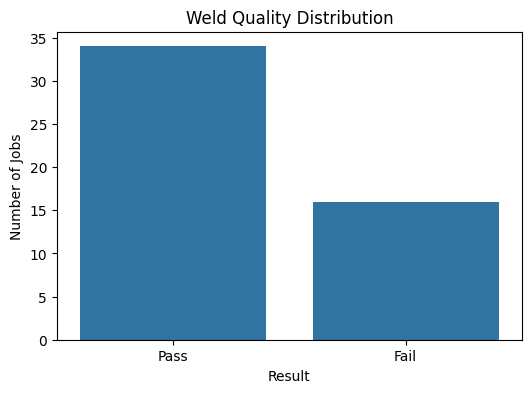

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Result"
)

plt.title("Weld Quality Distribution")
plt.xlabel("Result")
plt.ylabel("Number of Jobs")

plt.show()

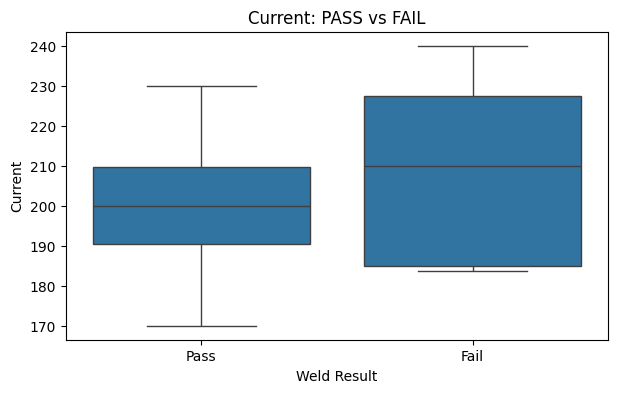

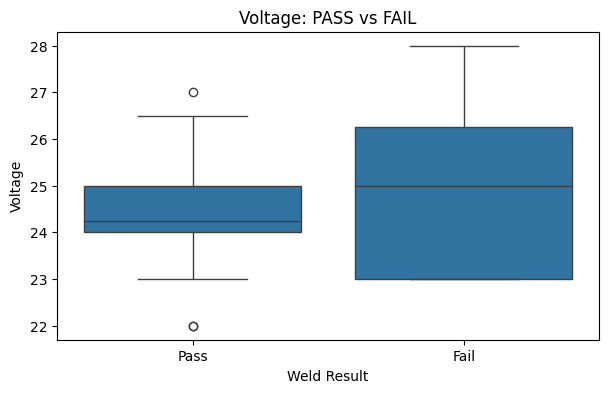

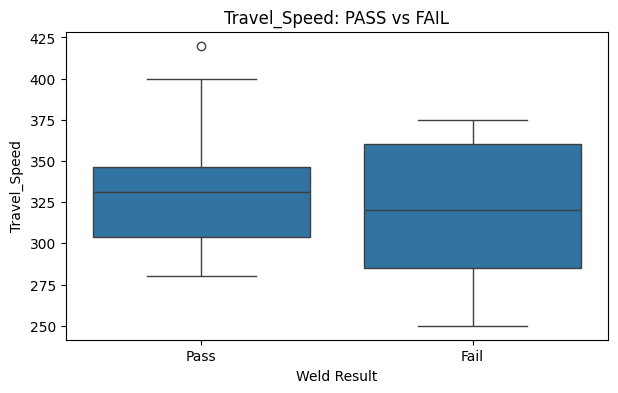

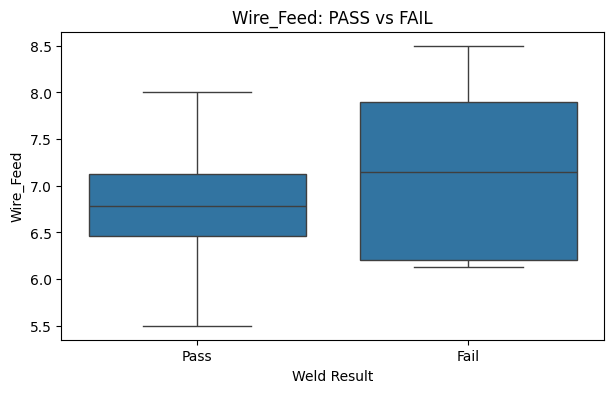

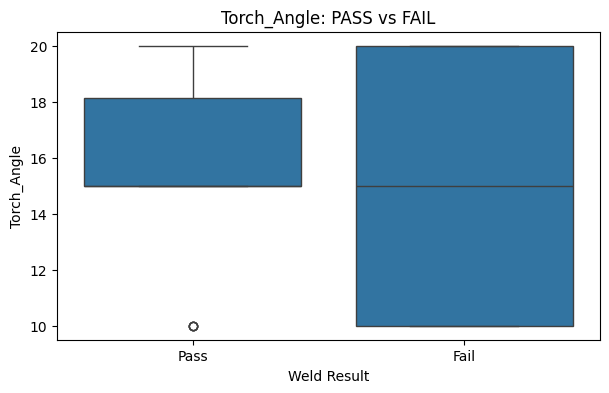

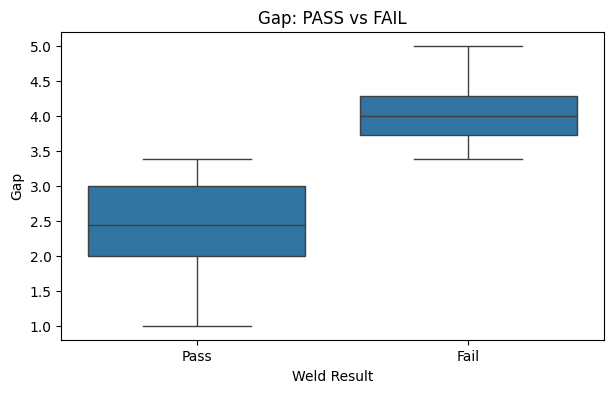

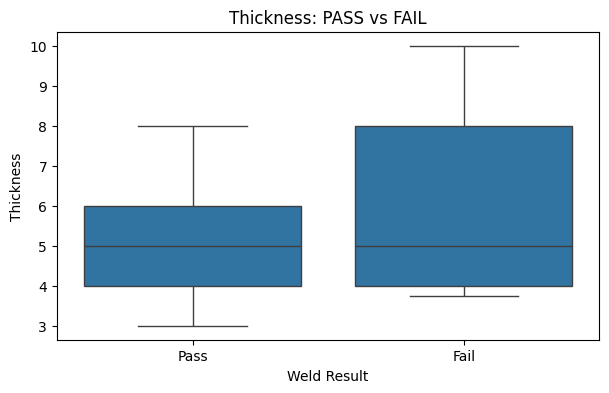

In [ ]:
for feature in features:

    plt.figure(figsize=(7,4))

    sns.boxplot(
        data=df,
        x="Result",
        y=feature
    )

    plt.title(f"{feature}: PASS vs FAIL")
    plt.xlabel("Weld Result")
    plt.ylabel(feature)

    plt.show()

# Correlation matrix

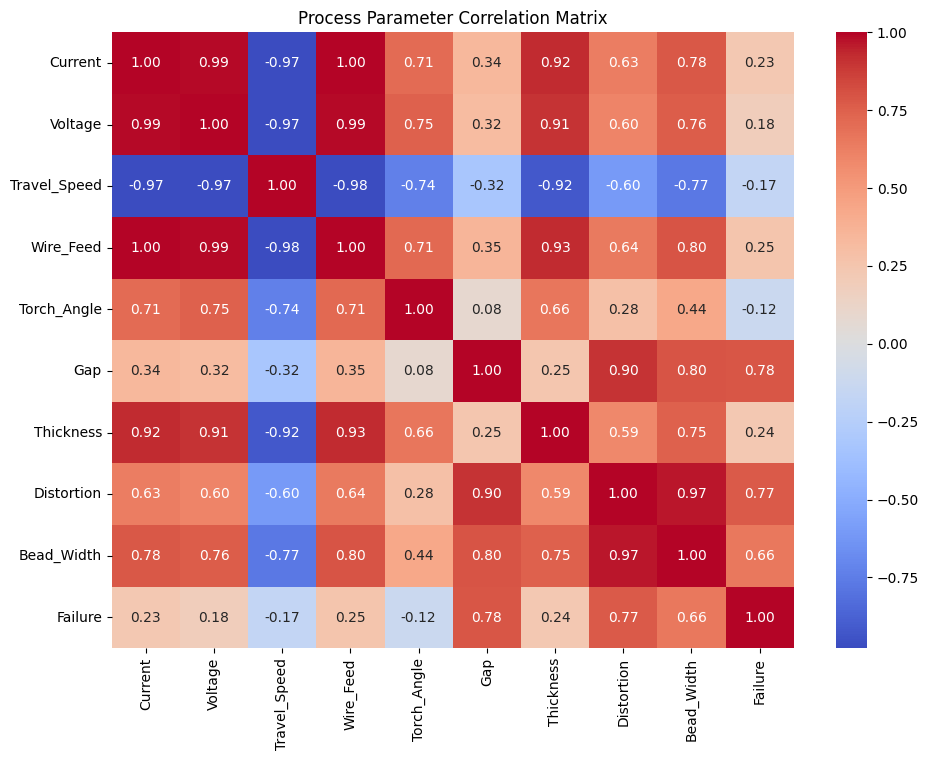

In [ ]:
plt.figure(figsize=(11,8))

corr = df[
    features +
    ["Distortion", "Bead_Width", "Failure"]
].corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Process Parameter Correlation Matrix")

plt.show()

In [ ]:
features = [
    "Current",
    "Voltage",
    "Travel_Speed",
    "Wire_Feed",
    "Torch_Angle",
    "Gap",
    "Thickness"
]

X = df[features]
output = df["Failure"]

print("X shape:", X.shape)
print("output shape:", output.shape)

NameError: name 'df' is not defined

In [ ]:
import pandas as pd
import numpy as np
from google.colab import drive

# Mount Google Drive
drive.mount("/content/drive")

# Load the actual CSV
path = "/content/drive/MyDrive/Final_Dataset.csv"

df = pd.read_csv(path)

# Clean column names
df.columns = (
    df.columns
    .astype(str)
    .str.strip()
)

# Rename columns
df = df.rename(columns={
    "Job ID": "Job_ID",
    "Current (A)": "Current",
    "Voltage (V)": "Voltage",
    "Travel Speed (mm/min)": "Travel_Speed",
    "Wire Feed Rate (m/min)": "Wire_Feed",
    "Torch Angle (Â°)": "Torch_Angle",
    "Torch Angle (°)": "Torch_Angle",
    "Gap Size (mm)": "Gap",
    "Thickness (mm)": "Thickness",
    "Distortion (mm)": "Distortion",
    "Bead Width (mm)": "Bead_Width",
    "Result": "Result"
})

# Clean Result
df["Result"] = (
    df["Result"]
    .astype(str)
    .str.strip()
    .str.capitalize()
)

# Create target
df["Failure"] = df["Result"].map({
    "Pass": 0,
    "Fail": 1
})

# Define model features
features = [
    "Current",
    "Voltage",
    "Travel_Speed",
    "Wire_Feed",
    "Torch_Angle",
    "Gap",
    "Thickness"
]

# Create X and y
X = df[features].copy()
y = df["Failure"].copy()

print("=" * 50)
print("DATASET READY")
print("=" * 50)

print("Dataset shape:", df.shape)
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nResult distribution:")
print(df["Result"].value_counts())

print("\nMissing values:")
print(df.isnull().sum())

Mounted at /content/drive
DATASET READY
Dataset shape: (50, 12)
X shape: (50, 7)
y shape: (50,)

Columns:
['Job_ID', 'Current', 'Voltage', 'Travel_Speed', 'Wire_Feed', 'Torch_Angle', 'Gap', 'Thickness', 'Distortion', 'Bead_Width', 'Result', 'Failure']

Result distribution:
Result
Pass    34
Fail    16
Name: count, dtype: int64

Missing values:
Job_ID          0
Current         0
Voltage         0
Travel_Speed    0
Wire_Feed       0
Torch_Angle     0
Gap             0
Thickness       0
Distortion      0
Bead_Width      0
Result          0
Failure         0
dtype: int64


# Training Model

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate

logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        max_iter=2000,
        random_state=42
    ))
])


tree_model = DecisionTreeClassifier(
    max_depth=3,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42
)


cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

models = {
    "Logistic Regression": logistic_model,
    "Decision Tree": tree_model
}


results = {}

for name, model in models.items():

    scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=scoring
    )

    results[name] = {
        metric: scores[f"test_{metric}"].mean()
        for metric in scoring
    }


results_df = pd.DataFrame(results).T

print("MODEL COMPARISON")
display(results_df.round(3))

MODEL COMPARISON


,accuracy,precision,recall,f1,roc_auc
Logistic Regression,0.94,1.00,0.800,0.860,1.000
Decision Tree,0.94,0.91,0.933,0.909,0.967


# Model Training
primary model-Decision tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

final_model = DecisionTreeClassifier(
    max_depth=3,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42
)

final_model.fit(X, y)

print("Final Decision Tree trained successfully.")

Final Decision Tree trained successfully.


In [ ]:
train_predictions = final_model.predict(X)

from sklearn.metrics import classification_report

print(
    classification_report(
        y,
        train_predictions,
        target_names=["PASS", "FAIL"]
    )
)

              precision    recall  f1-score   support

        PASS       1.00      0.94      0.97        34
        FAIL       0.89      1.00      0.94        16

    accuracy                           0.96        50
   macro avg       0.94      0.97      0.96        50
weighted avg       0.96      0.96      0.96        50



In [ ]:
from sklearn.tree import export_text

tree_rules = export_text(
    final_model,
    feature_names=features
)

print(tree_rules)

|--- Gap <= 3.31
|   |--- class: 0
|--- Gap >  3.31
|   |--- Gap <= 3.44
|   |   |--- class: 1
|   |--- Gap >  3.44
|   |   |--- class: 1



So when J021 arrives, we need to give the model those same 7 inputs in the same structure.
trained model expects tabular input with the same 7 feature columns it was trained on.

Your model was trained with:

# Create J021 Dataframe

In [ ]:
challenge_input= pd.DataFrame({
    "Current": [190],
    "Voltage": [24],
    "Travel_Speed": [350],
    "Wire_Feed": [6.5],
    "Torch_Angle": [15],
    "Gap": [4.5],
    "Thickness": [5]
})

display(challenge_input)

,Current,Voltage,Travel_Speed,Wire_Feed,Torch_Angle,Gap,Thickness
0,190,24,350,6.5,15,4.5,5


# Pass/Fail Prediction

In [ ]:
predicts=final_model.predict(challenge_input)
result={
"Fail"
if predicts[0]==1
else
"Pass"
}
print("J021 Prediction :", result)

J021 Prediction : {'Fail'}


# Failure Probability

In [ ]:
j021_probability = final_model.predict_proba(challenge_input)[0]

print(f"PASS probability : {j021_probability[0] * 100:.2f}%")
print(f"FAIL probability : {j021_probability[1] * 100:.2f}%")

PASS probability : 0.00%
FAIL probability : 100.00%


In [ ]:
confidence = max(j021_probability)

if confidence >= 0.80:
    confidence_level = "HIGH"
elif confidence >= 0.60:
    confidence_level = "MEDIUM"
else:
    confidence_level = "LOW"

print(f"Decision confidence : {confidence * 100:.2f}%")
print(f"Confidence level    : {confidence_level}")

Decision confidence : 100.00%
Confidence level    : HIGH


In [ ]:
import joblib

model_path = "/content/drive/MyDrive/welding_quality_model.pkl"

joblib.dump(final_model, model_path)

print("Model saved successfully!")
print(model_path)

Model saved successfully!
/content/drive/MyDrive/welding_quality_model.pkl


# WHY did J021 fail?